# KMeans 개선안 9: 비선형 차원축소 (t-SNE / UMAP) 사용

기존의 **PCA(주성분 분석)**는 데이터의 선형적인 관계성만 축소하므로 고차원 이미지 데이터의 복잡한 굴곡(다양체, Manifold)을 완벽하게 펴지 못합니다. 

이 실험에서는 복잡한 고차원 데이터의 이웃 관계(Neighboring relationship)를 저차원 확률 분포에 투영하는 강력한 비선형 차원 축소 기법인 **t-SNE**와 **UMAP**을 적용하여 10,000차원의 픽셀을 단 **2차원(2D)**으로 매핑합니다.

투영된 2차원 좌표 위에서 KMeans 군집화를 실행하여 기하학적으로 얼마나 완벽하게 과일들이 3개의 집단으로 분리되는지 확인합니다.

In [1]:
# 필요한 라이브러리 자동 설치
!pip install -q umap-learn

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# 1. 데이터 로드 및 2차원 평면 가공
data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100 * 100)

# 데이터 표준화
scaler = StandardScaler()
fruits_scaled = scaler.fit_transform(fruits_2d)

# 실제 과일 정답 클래스 정의 (시각화 비교용)
# 첫 100개: 사과(0), 다음 100개: 파인애플(1), 마지막 100개: 바나나(2)
ground_truth = np.array([0]*100 + [1]*100 + [2]*100)
fruit_names = ['Apple', 'Pineapple', 'Banana']

## 1단계: 선형 차원축소 (PCA) 결과 시각화

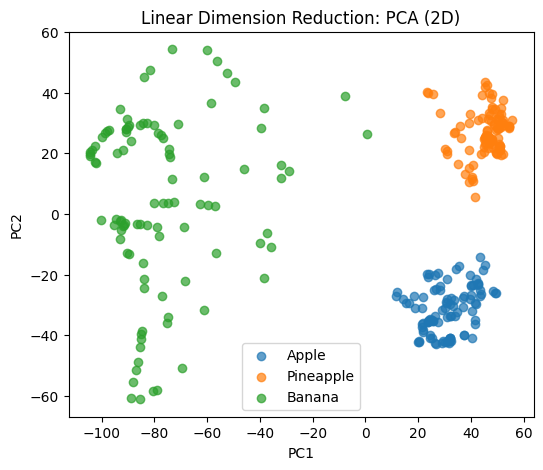

In [3]:
# PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(fruits_scaled)

# 시각화
plt.figure(figsize=(6, 5))
for i, fruit_name in enumerate(fruit_names):
    idx = np.where(ground_truth == i)
    plt.scatter(pca_coords[idx, 0], pca_coords[idx, 1], label=fruit_name, alpha=0.7)
plt.title('Linear Dimension Reduction: PCA (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 2단계: 비선형 차원축소 (t-SNE) 결과 시각화

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


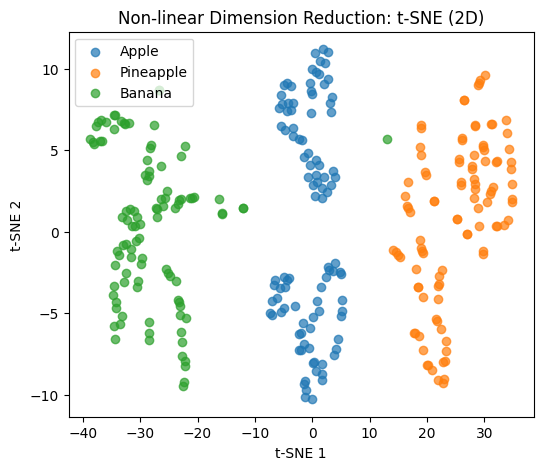

In [4]:
# t-SNE로 2차원 축소
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_coords = tsne.fit_transform(fruits_scaled)

# 시각화
plt.figure(figsize=(6, 5))
for i, fruit_name in enumerate(fruit_names):
    idx = np.where(ground_truth == i)
    plt.scatter(tsne_coords[idx, 0], tsne_coords[idx, 1], label=fruit_name, alpha=0.7)
plt.title('Non-linear Dimension Reduction: t-SNE (2D)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.show()

## 3단계: 최신 비선형 차원축소 (UMAP) 결과 시각화

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


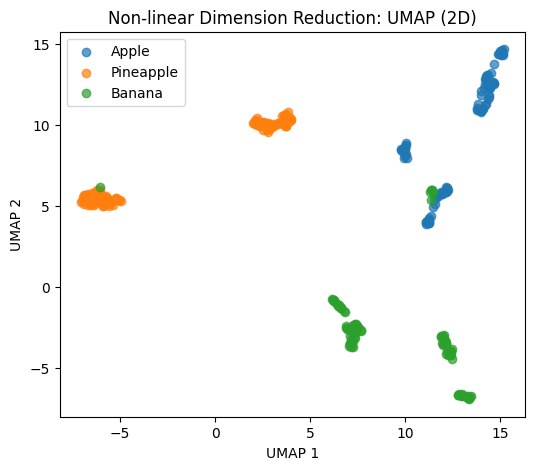

In [5]:
# UMAP으로 2차원 축소
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_coords = reducer.fit_transform(fruits_scaled)

# 시각화
plt.figure(figsize=(6, 5))
for i, fruit_name in enumerate(fruit_names):
    idx = np.where(ground_truth == i)
    plt.scatter(umap_coords[idx, 0], umap_coords[idx, 1], label=fruit_name, alpha=0.7)
plt.title('Non-linear Dimension Reduction: UMAP (2D)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.show()

## 4단계: UMAP 2차원 좌표 기반 KMeans 군집화 수행

UMAP을 통해 3개의 대륙처럼 아주 맑고 뚜렷하게 분리된 2D 공간 좌표를 입력으로 KMeans를 동작시켜 봅니다.

Labels distribution: (array([0, 1, 2], dtype=int32), array([101,  93, 106]))
Final Silhouette Score (on UMAP coords): 0.6316909
Final Davies-Bouldin Score (on UMAP coords): 0.590865327830061


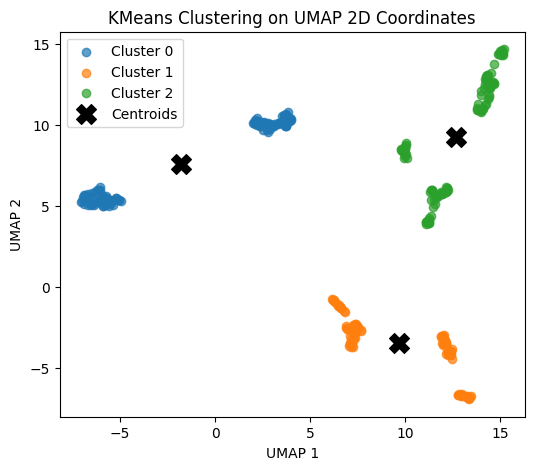

In [6]:
# UMAP 2D 좌표로 KMeans 학습
km = KMeans(n_clusters=3, n_init=20, random_state=42)
umap_labels = km.fit_predict(umap_coords)

print('Labels distribution:', np.unique(umap_labels, return_counts=True))
print('Final Silhouette Score (on UMAP coords):', silhouette_score(umap_coords, umap_labels))
print('Final Davies-Bouldin Score (on UMAP coords):', davies_bouldin_score(umap_coords, umap_labels))

# KMeans 분류 결과 시각화
plt.figure(figsize=(6, 5))
for cluster_id in range(3):
    idx = np.where(umap_labels == cluster_id)
    plt.scatter(umap_coords[idx, 0], umap_coords[idx, 1], label=f'Cluster {cluster_id}', alpha=0.7)

# KMeans 중심점 시각화
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title('KMeans Clustering on UMAP 2D Coordinates')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.show()

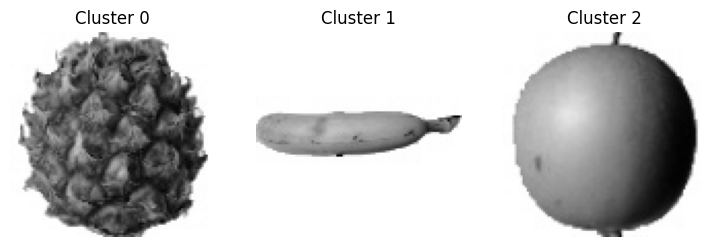

In [7]:
# 5. 각 군집별 대표 샘플 시각화
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for cluster_id, ax in enumerate(axs):
    sample_index = np.where(umap_labels == cluster_id)[0][0]
    ax.imshow(fruits[sample_index], cmap='gray_r')
    ax.set_title(f'Cluster {cluster_id}')
    ax.axis('off')
plt.show()